# ARITRA
#`MCS202304`

In [ ]:
# Installing necessary packages
!pip install nltk --quiet
!pip install prettytable --quiet

In [ ]:
# Importing necessary packages
import os
import math
import random
import multiprocessing
from multiprocessing import Pool
import zipfile
import json
import re
import nltk
import numpy as np
from nltk.probability import FreqDist
import matplotlib.pyplot as plt
from prettytable import PrettyTable
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from tqdm import tqdm
import h5py
from collections import Counter
import pandas as pd
import pickle
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import pairwise_distances
from sklearn.manifold import MDS
import tensorflow as tf
from sklearn.manifold import TSNE
from tensorflow.keras import layers
import warnings

warnings.filterwarnings("ignore")

In [ ]:
# Define stopwords

nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

# Connecting to `TPU`

In [ ]:
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    print('Running on TPU ', tpu.master())
except ValueError:
    tpu = None

if tpu:
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.experimental.TPUStrategy(tpu)
else:
    strategy = tf.distribute.get_strategy()

print("REPLICAS: ", strategy.num_replicas_in_sync)

REPLICAS:  1


Get the number of cpu cores

In [ ]:
num_cores = os.cpu_count() or multiprocessing.cpu_count()

print(f"Number of CPU cores: {num_cores}")

Number of CPU cores: 4


In [ ]:
# Define GLOBAL Variables

VOCABULARY_COUNT = 10000 #total vocab size (fixed)
FILE_COUNT = 56528 #Total no. of json files
NUM_CORES = num_cores
AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
writing_dir = "/kaggle/working/"
working_dir = "/kaggle/input/"
os.chdir(os.path.join(working_dir, "pdf-json/pdf_json"))

Varables from this part were retrieved from the `pickle` file

In [ ]:
files_list = os.listdir()
json_files = [f for f in files_list if os.path.isfile(f) and f.endswith(".json")]

In [ ]:
print(f"No. of JSON files: {len(json_files)}")

In [ ]:
json_files = json_files[:FILE_COUNT]

In [ ]:
def json2text(filename):
    """Get the file given filename and extract text from it"""
    file = open(filename)

    paper_content = json.load(file)
    body_text = ""
    abstract = ""
    title = ""

    # Get the paper_id
    paper_id = paper_content["paper_id"]

    # Get the title
    if "title" in paper_content:
        title = paper_content["title"]

    # Get the abstract
    if "abstract" in paper_content:
        for abs in paper_content["abstract"]:
            abstract = abstract + abs["text"]

    # Get the paper
    if "body_text" in paper_content:
        for bt in paper_content["body_text"]:
            body_text = body_text + bt["text"]

    return (f"{title} {abstract} {body_text}").lower()

In [ ]:
# Define global stopwords
stop_words = set(stopwords.words("english"))

In [ ]:
def preprocess(text):
    """
    Preprocess the text in following order:
    - Remove digits.
    - Removes punctuation marks, symbols, special characters, etc.
    - tokenize the text into words.
    - Filter the alphanmeuric words.
    - Get the frequency distribution
    """
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    words = word_tokenize(text)
    words = [word.lower() for word in words if word.isalpha()]
    words = [
        word.lower()
        for word in words
        if word not in stop_words and word not in ["et", "al"] and len(word) > 2 and word.isalpha()
    ]
    return words

In [ ]:
def process_file(file):
    """Process a single file, runs num_cores and preprocess text sequentially and returns consecutive words."""
    text = json2text(file)
    words_list = preprocess(text)
    return words_list

In [ ]:
with multiprocessing.Pool(num_cores) as pool:
    words_lists = list(
        tqdm(
            pool.imap_unordered(process_file, json_files),
            total=len(json_files),
            desc="Reading jsons",
        )
    )

# Assignment 4

In [ ]:
# Flatten the list of lists to list
words = [item for sublist in words_lists for item in sublist]

In [ ]:
# Retrieve vocabulary and context words

vocab = set()
context_words = []
for word in words:
    if len(vocab) == VOCABULARY_COUNT:
        break
    vocab.add(word)
    context_words.append(word)

## Define `bijection` between `words` and `indices`

In [ ]:
word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

idx2word[word2idx["pandemic"]]

pandemic


# Function to calculate `one hot vector` for each word

In [ ]:
def OHV(word):
    vector = np.zeros(VOCABULARY_COUNT)
    if word in vocab:
        vector[word2idx[word]] = 1
    return vector

In [ ]:
one_hot_vectors = np.array([OHV(word) for word in vocab])

Here we try to fit a skipgram model on the COVID19 corpus with a vocab of 10k words.
We have tried to tokenize as sentence with `window size` 10.


In [ ]:
corpus_lines = []
for i in range(0, len(context_words), 10):
    corpus_line = ' '.join(context_words[i:i + 10])
    corpus_lines.append(corpus_line)

# Create a TensorFlow dataset from the lines
text_lines_ds = tf.data.Dataset.from_tensor_slices(corpus_lines)

# Filter out empty lines
text_lines_ds = text_lines_ds.filter(lambda x: tf.cast(tf.strings.length(x), bool))

# Use the `TextVectorization` layer to vectorize sentences

This will help train the `skipgram` model in batches

In [ ]:
import string

def standardization(input_data):
  lowercase = tf.strings.lower(input_data)
  return tf.strings.regex_replace(lowercase, '[%s]' % re.escape(string.punctuation), '')


vocab_size = 10000
sequence_length = 10

vectorize = layers.TextVectorization(
    standardize=standardization,
    max_tokens=vocab_size,
    output_mode='int',
    output_sequence_length=sequence_length)

In [ ]:
vectorize.adapt(text_lines_ds.batch(1024))

Once the state of the layer has been adapted to represent the text corpus, the vocabulary can be accessed with

```python
TextVectorization.get_vocabulary()
```

This function returns a list of all vocabulary tokens sorted (descending) by their frequency.

In [ ]:
inverse_vocab = vectorize.get_vocabulary()
print(inverse_vocab[:20])

['covid', 'study', 'data', 'also', 'infection', 'disease', 'health', 'clinical', 'protein', 'information', 'response', 'system', 'one', 'fig', 'including', 'pedv', 'different', 'und', 'cases', 'wfo']


The `vectorize_layer` can now be used to generate vectors for each element in the text_ds (a `tf.data.Dataset`).

In [ ]:
text_vector = text_lines_ds.batch(1024).prefetch(AUTOTUNE).map(vectorize).unbatch()

# Obtain sequences from the dataset
- We now have a `tf.data.Dataset` of integer encoded sentences. To prepare the dataset for training a skipgram model, we flatten the dataset into a list of sentence vector sequences. This step is required as we would iterate over each sentence in the dataset to produce positive and negative examples.

In [ ]:
text_sequences = list(text_vector.as_numpy_iterator())

# Let's inspect a few examples from sequences:

In [ ]:
for seq in text_sequences[:5]:
  print(f"{seq} => {[inverse_vocab[i] for i in seq]}")

[1095 4398 1161 2430  491    9  213  304 2088 1043] => ['distancing', 'handwashingin', 'regard', 'mcdonalds', 'comments', 'virus', 'size', 'whether', 'filtered', 'respirators']
[  73  159  437 2049 3296  323 4988   53  213  440] => ['would', 'like', 'point', 'issued', 'correction', 'paper', 'accepting', 'important', 'size', 'particles']
[ 575    9  213    9 4253   73  159  687 2430 4794] => ['containing', 'virus', 'size', 'virus', 'itselfsecond', 'would', 'like', 'address', 'mcdonalds', 'claim']
[4287 1075 1551 2482 3222   54  152 4594  272 1075] => ['installing', 'hepa', 'filters', 'homes', 'eliminate', 'risk', 'air', 'duct', 'transmission', 'hepa']
[1551  973 2848  440 1844 2292 1915  152   15  792] => ['filters', 'good', 'removing', 'particles', 'broad', 'spectrum', 'sizes', 'air', 'however', 'filter']


# Generate training examples from sequences
As we have a list of ints that are encoding of words,
- We can just call the `generate_training_data` function defined earlier to generate training examples for the skipgram model.
- Length of target, contexts and labels should be the same, representing the total number of training examples.

In [ ]:
def generate_data_for_training(sequences, window_size, num_ns, vocab_size, seed):
  targets, contexts, labels = [], [], []

  sampling_table = tf.keras.preprocessing.sequence.make_sampling_table(vocab_size)

  for sequence in tqdm(sequences):

    positive_skip_grams, _ = tf.keras.preprocessing.sequence.skipgrams(
          sequence,
          vocabulary_size=vocab_size,
          sampling_table=sampling_table,
          window_size=window_size,
          negative_samples=0)

    # Iterate over each positive skip-gram pair to produce training examples with a positive context word and negative samples.
    for target_word, context_word in positive_skip_grams:
      context_class = tf.expand_dims(
          tf.constant([context_word], dtype="int64"), 1)
      negative_sampling_candidates, _, _ = tf.random.log_uniform_candidate_sampler(
          true_classes=context_class,
          num_true=1,
          num_sampled=num_ns,
          unique=True,
          range_max=vocab_size,
          seed=seed,
          name="negative_sampling")

      # Build context and label vectors (for one target word)
      context = tf.concat([tf.squeeze(context_class,1), negative_sampling_candidates], 0)
      label = tf.constant([1] + [0]*num_ns, dtype="int64")

      # Append each element from the training example to global lists.
      targets.append(target_word)
      contexts.append(context)
      labels.append(label)

  return targets, contexts, labels

In [ ]:
targets, contexts, labels = generate_data_for_training(
    sequences=text_sequences,
    window_size=2,
    num_ns=5,
    vocab_size=vocab_size,
    seed=10)

training_targets = np.array(targets)
training_contexts = np.array(contexts)
training_labels = np.array(labels)

print('\n')
print(f"targets.shape: {training_targets.shape}")
print(f"contexts.shape: {training_contexts.shape}")
print(f"labels.shape: {training_labels.shape}")


100%|██████████| 4779/4779 [00:14<00:00, 332.80it/s]




targets.shape: (48967,)
contexts.shape: (48967, 6)
labels.shape: (48967, 6)


We need to do efficient batching of size 1024, so we use the `tf.data.Dataset` API.

In [ ]:
BATCH_SIZE = 1024
BUFFER_SIZE = 10000
text_dataset = tf.data.Dataset.from_tensor_slices(((training_targets, training_contexts), training_labels))
text_dataset = text_dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)

# Apply `Dataset.cache` and `Dataset.prefetch` to improve performance

In [ ]:
dataset = text_dataset.cache().prefetch(buffer_size=AUTOTUNE)

# Build `Skipgram` model

In [ ]:
class SkipGramModel(tf.keras.Model):
  def __init__(self, vocab_size, embedding_dim):
    super(SkipGramModel, self).__init__()
    self.target_embedding = layers.Embedding(vocab_size,
                                      embedding_dim,
                                      name="word_embedding")
    self.context_embedding = layers.Embedding(vocab_size,
                                       embedding_dim,
                                       name="context_embedding")

  def call(self, pair):
    target, context = pair
    if len(target.shape) == 2:
      target = tf.squeeze(target, axis=1)
    word_emb = self.target_embedding(target)
    context_emb = self.context_embedding(context)
    dots = tf.einsum('be,bce->bc', word_emb, context_emb)
    return dots

### Understanding the Skip-Gram Neural Network with Negative Sampling

This outlines a word embedding system built with TensorFlow/Keras that uses the **Skip-Gram approach**. Here's how the system is structured:

#### 1. **Custom Model Implementation**:
The architecture leverages **Keras' custom model functionality** through subclassing, enabling precise control over how the network processes word pairs during training.

#### 2. **Dual Embedding Architecture**:
The model features two distinct embedding matrices:
- A **word matrix** transforms the main input word into a dense vector
- A separate **context matrix** handles the surrounding words
  
This dual-matrix approach helps the model differentiate between a word's behavior when it's the focus versus when it appears in another word's context.

#### 3. **Processing Pipeline**:
The model's core logic (implemented in the `call` function) works as follows:
- Ensures input consistency by converting 2D target inputs into 1D when needed
- Maps both the target and context words into their respective vector spaces using the dual embedding system
- Computes word-context relationships through a **bilinear similarity calculation** using `einsum` operations, generating relevance scores for each word pair

#### 4. **Final Output**:
The system produces similarity metrics between each target-context word pair. These measurements feed into the **negative sampling training process**, which helps the model learn meaningful word representations.

By keeping these elements separate yet interconnected, the model can effectively capture the nuanced relationships between words in a given corpus.

# Call `skipgram` class with an `embedding dimension` of `128`

In [ ]:
embedding_dim = 128
skipgram_model = SkipGramModel(vocab_size, embedding_dim)
skipgram_model.compile(optimizer='adam',
                 loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
                 metrics=['accuracy'])

In [ ]:
# Architecture of the skipgram model
skipgram_model.summary()

Model: "skip_gram_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ target_embedding (Embedding)         │ (1024, 128)                 │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ context_embedding (Embedding)        │ (1024, 5, 128)              │       1,280,000 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,680,002 (29.30 MB)

 Trainable params: 2,560,000 (9.77 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,120,002 (19.53 MB)

In [ ]:
# This callback derivation basically tracks the loss after each epoch
from tensorflow.keras.callbacks import Callback

class LossTracker(Callback):
    def __init__(self):
        super().__init__()
        self.losses = []

    def on_epoch_end(self, epoch, logs=None):
        self.losses.append(logs.get('loss'))

loss = LossTracker()

# Plot of `training error` vs `epoch`

Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.1730 - loss: 1.7915
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7325 - loss: 1.7734
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9217 - loss: 1.7433
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9332 - loss: 1.6645
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9007 - loss: 1.5302
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8783 - loss: 1.3935
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8799 - loss: 1.2657
Epoch 8/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8990 - loss: 1.1376
Epoch 9/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9251 - loss: 1.0068
Epoch 10/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9483 - loss: 0.8749
Epoch 11/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9645 - loss: 0.7496
Epoch 12/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy:

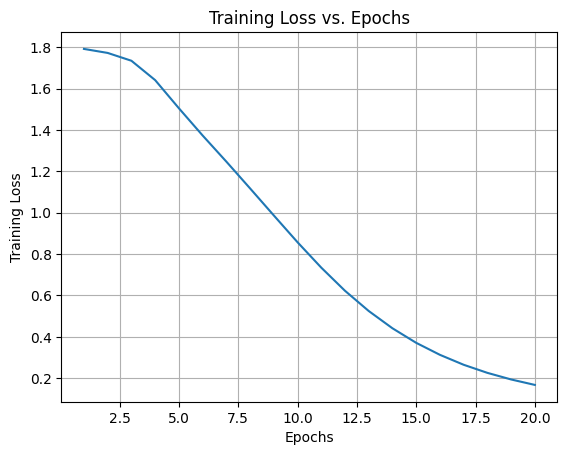

In [ ]:
skipgram_model.fit(text_dataset, epochs=20, callbacks=[loss])

plt.plot(np.arange(1, len(loss.losses) + 1), loss.losses)
plt.xlabel('Epochs')
plt.ylabel('Training Loss')
plt.title('Training Loss vs. Epochs')
plt.grid()
plt.show()

# Test analogies
The following function basically mimics the following calculation.
```
India : New Delhi :: Japan : ?? (Tokyo)
```

In [ ]:
def test_analogy(model, inverse_vocab, target_word, context_word, new_target_word):
    """
    Predicts the analogous word using skipgram.

    Takes target, context and new_target
    For all words in vocab, calculate the vector new_context - word
    Return the word with the vector cloasest to the vector target - context
    """
    try:
        target_index = inverse_vocab.index(target_word)
        context_index = inverse_vocab.index(context_word)

        new_target_index = inverse_vocab.index(new_target_word)

        # Get the word vectors
        target_vector = skipgram_model.get_layer('word_embedding').get_weights()[0][target_index]
        context_vector = skipgram_model.get_layer('context_embedding').get_weights()[0][context_index]

        new_target_vector = skipgram_model.get_layer('word_embedding').get_weights()[0][new_target_index]


        # Find the word with the closest vector to the difference between the input vectors
        vector_differences = []
        for word in tqdm(vocab):
            try:
                word_vector = skipgram.get_layer('context_embedding').get_weights()[0][inverse_vocab.index(word)]
                vector_differences.append((abs(np.linalg.norm((word_vector - new_target_vector) - (context_vector - target_vector))), word))
            except:
                continue

        vector_differences.sort()
        _, predicted_word = vector_differences[0]

        return predicted_word

    except ValueError:
        return "Word not found in vocabulary"


In [ ]:
predicted = test_analogy(skipgram_model, inverse_vocab, "patients", "lockdown", "saline")
print(f"'patients':'lockdown' implies 'saline':'{predicted}'")

100%|██████████| 10000/10000 [00:15<00:00, 648.82it/s]

'patients':'lockdown' implies 'saline':'aquatic'


In [ ]:
predicted = predict_word(skipgram, inverse_vocab, "covid", "isolation", "hospital")
print(f"'covid':'isolation' implies 'hospital':'{predicted}'")

100%|██████████| 10000/10000 [00:16<00:00, 624.03it/s]

'covid':'isolation' implies 'hospital':'admit'


In [ ]:
predicted = predict_word(skipgram, inverse_vocab, "saline", "patients", "diagnosis")
print(f"'treatment':'fever' implies 'diagnosis':'{predicted}'")

100%|██████████| 10000/10000 [00:15<00:00, 647.18it/s]

'treatment':'fever' implies 'diagnosis':'stopped'


In [ ]:
predicted = predict_word(skipgram, inverse_vocab, "disease", "virus", "pandemic")
print(f"'disease':'virus' implies 'pandemic':'{predicted}'")

100%|██████████| 10000/10000 [00:15<00:00, 660.95it/s]

'disease':'virus' implies 'pandemic':'supplementation'


In [ ]:
predicted = predict_word(skipgram, inverse_vocab, "disease", "deteriorate", "precautions")
print(f"'disease':'deteriorate' implies 'precautions':'{predicted}'")

100%|██████████| 10000/10000 [00:15<00:00, 665.45it/s]


'disease':'deteriorate' implies 'precautions':'utilization'


In [ ]:
predicted = predict_word(skipgram, inverse_vocab, "awards", "winners", "nominations")
print(f"'awards':'winners' implies 'nominations':'{predicted}'")

100%|██████████| 10000/10000 [00:15<00:00, 630.55it/s]

'awards':'winners' implies 'nominations':'certification'


# Assignment 5

# Example of similar words for `haemoglobin` using W_in

In [ ]:
weights = skipgram_model.get_layer('word_embedding').get_weights()[0]

target_word = "haemoglobin"
target_word_index = inverse_vocab.index(target_word)

target_word_embedding = weights[target_word_index]

similarities = np.dot(weights, target_word_embedding) / (np.linalg.norm(weights, axis=1) * np.linalg.norm(target_word_embedding))

most_similar_indices = np.argsort(similarities)[::-1][1:6]  # Get top 5 similar words

# Print the most similar words and their similarities.
print(f"Context words for '{target_word}':")
for index in most_similar_indices:
    context_word = inverse_vocab[index]
    similarity = similarities[index]
    print(f"- {context_word}: {similarity:.4f}")

Context words for 'haemoglobin':
- covinduced: 0.4785
- glycated: 0.4077
- understanding: 0.3907
- excretion: 0.3813
- alongside: 0.3699


# Example of similar word for `pandemic` using W_in

In [ ]:
weights = skipgram_model.get_layer('word_embedding').get_weights()[0]

target_word = "pandemic"
target_word_index = inverse_vocab.index(target_word)

target_word_embedding = weights[target_word_index]

similarities = np.dot(weights, target_word_embedding) / (np.linalg.norm(weights, axis=1) * np.linalg.norm(target_word_embedding))

most_similar_indices = np.argsort(similarities)[::-1][1:6]  # Get top 5 similar words

print(f"Context words for '{target_word}':")
for index in most_similar_indices:
    context_word = inverse_vocab[index]
    similarity = similarities[index]
    print(f"- {context_word}: {similarity:.4f}")

Context words for 'pandemic':
- africanamericans: 0.4885
- bei: 0.4801
- socio: 0.4572
- stethoscope: 0.4507
- falle: 0.4426


# Example of similar word for `pandemic` using `W_out`

In [ ]:
weights = skipgram_model.get_layer('context_embedding').get_weights()[0]

target_word = "pandemic"
target_word_index = inverse_vocab.index(target_word)

target_word_embedding = weights[target_word_index]

similarities = np.dot(weights, target_word_embedding) / (np.linalg.norm(weights, axis=1) * np.linalg.norm(target_word_embedding))

most_similar_indices = np.argsort(similarities)[::-1][1:6]  # Get top 5 similar words

# Print the most similar words and their similarities.
print(f"Context words for '{target_word}':")
for index in most_similar_indices:
    context_word = inverse_vocab[index]
    similarity = similarities[index]
    print(f"- {context_word}: {similarity:.4f}")

Context words for 'pandemic':
- covid: 0.5604
- educated: 0.5542
- preemptively: 0.5460
- shields: 0.5450
- dicer: 0.5440


# Example of similar word for `pandemic` after averaging `W_in` and `W_out`

In [ ]:
weights1 = skipgram_model.get_layer('context_embedding').get_weights()[0]
weights2 = skipgram_model.get_layer('word_embedding').get_weights()[0]
weights = (weights1 + weights2)/2

target_word = "pandemic"
target_word_index = inverse_vocab.index(target_word)

target_word_embedding = weights[target_word_index]

similarities = np.dot(weights, target_word_embedding) / (np.linalg.norm(weights, axis=1) * np.linalg.norm(target_word_embedding))

most_similar_indices = np.argsort(similarities)[::-1][1:6]  # Get top 5 similar words

# Print the most similar words and their similarities.
print(f"Context words for '{target_word}':")
for index in most_similar_indices:
    context_word = inverse_vocab[index]
    similarity = similarities[index]
    print(f"- {context_word}: {similarity:.4f}")

Context words for 'pandemic':
- nonhealthcare: 0.7238
- organizationamid: 0.6713
- struck: 0.6583
- rescheduled: 0.6401
- socio: 0.6387


# Example of similar word for `hospital` after averaging `W_in` and `W_out`

In [ ]:
weights1 = skipgram_model.get_layer('context_embedding').get_weights()[0]
weights2 = skipgram_model.get_layer('word_embedding').get_weights()[0]
weights = (weights1 + weights2)/2

target_word = "hospital"
target_word_index = inverse_vocab.index(target_word)

target_word_embedding = weights[target_word_index]

similarities = np.dot(weights, target_word_embedding) / (np.linalg.norm(weights, axis=1) * np.linalg.norm(target_word_embedding))

most_similar_indices = np.argsort(similarities)[::-1][1:6]  # Get top 5 similar words

# Print the most similar words and their similarities.
print(f"Context words for '{target_word}':")
for index in most_similar_indices:
    context_word = inverse_vocab[index]
    similarity = similarities[index]
    print(f"- {context_word}: {similarity:.4f}")

Context words for 'hospital':
- childrens: 0.6210
- seattle: 0.5943
- flagship: 0.5742
- isolation: 0.5537
- bilirubin: 0.4943


# Example of similar word for `precautions` after averaging `W_in` and `W_out`

In [ ]:
weights1 = skipgram_model.get_layer('context_embedding').get_weights()[0]
weights2 = skipgram_model.get_layer('word_embedding').get_weights()[0]
weights = (weights1 + weights2)/2

target_word = "precautions"s
target_word_index = inverse_vocab.index(target_word)

target_word_embedding = weights[target_word_index]

similarities = np.dot(weights, target_word_embedding) / (np.linalg.norm(weights, axis=1) * np.linalg.norm(target_word_embedding))

most_similar_indices = np.argsort(similarities)[::-1][1:6]  # Get top 5 similar words

# Print the most similar words and their similarities.
print(f"Context words for '{target_word}':")
for index in most_similar_indices:
    context_word = inverse_vocab[index]
    similarity = similarities[index]
    print(f"- {context_word}: {similarity:.4f}")

Context words for 'precautions':
- exemptions: 0.4856
- utilization: 0.4782
- order: 0.4618
- prevent: 0.4474
- concrete: 0.4224


# Assignment5
# Answer 4

- I have explored similar words for `pandemic` using different approaches: W_in, W_out, and a combination of both. The combined approach of W_in and W_out yielded the most relevant results. Using W_in alone produced some irrelevant predictions, while W_out maintained better relevance without such outliers.

- The words identified through W_in tend to capture grammatical and syntactic relationships, while W_out better represents semantic and conceptual similarities.

- By merging W_in and W_out approaches, we achieve a more comprehensive analysis that incorporates both linguistic function and meaning, resulting in a more balanced and accurate set of word associations.

# Assignment5
# Answer 5

`Skip-Gram` with `Negative Sampling` achieves computational efficiency by using a simplified training approach. Rather than processing the entire vocabulary for probability calculations, it focuses on a targeted subset of words, making it significantly more efficient than traditional methods.

The model's computational complexity is expressed as `𝑂(𝑇⋅𝑁⋅𝐶⋅𝑘)`, where:

- 𝑇: Total word count in the training corpus
- 𝑁: Number of dimensions in the word embedding space
- 𝐶: Context window length
- 𝑘: Number of negative samples per target word (significantly smaller than total vocabulary)

This optimization dramatically reduces computational overhead by sampling only k negative examples for each positive word pair, instead of evaluating against every word in the vocabulary during the softmax computation.